# TP3 - Convolutional NN

In [2]:
# Imports et initialisations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from pathlib import Path
from keras import layers

# Création d'un dossier "models" où stocker les modèles
MODEL_FOLDER ="models"
Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()
    
def show_errors_img(X, Y_pred, Y_true, shape=(28,28), dpi=100):  
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    n = min(len(X), len(Y_pred), len(Y_true), 30) # 30 erreurs au maximum
    X, Y_pred, Y_true = X[:n], Y_pred[:n], Y_true[:n]
    nl = n // 10
    if n%10!=0: nl += 1 
    
    for i in range(n):
        plt.subplot(nl,10,i+1)
        x, yp, yt = X[i], Y_pred[i], Y_true[i]
        plt.imshow(x.reshape(shape), cmap='gray')
        plt.axis('off')
        plt.title(str(yp)+' ('+str(yt)+')')
    plt.plot()
    
def show_model_errors(model, X, y):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)

    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    show_errors_img(X[errors], y_pred[errors], y[errors])

## Exercice 1
a) Implémenter le modèle LeNet-5 vu en cours et le tester sur les données MNIST.

Les données d'entrée devront être normalisées. L'apprentissage se fera sur 12 itérations avec des batchs de taille 128 et en utilisant la méthode de gradient Adam avec les paramètres par défaut.

Afficher des graphiques montrant l'évolution du coût et de la précision (accuracy), calculés sur les ensembles de d'apprentissage et de tests, au fur-et-à-mesure des itérations. 

Le modèle, une fois entraîné, sera stocké dans un fichier afin de pouvoir être utilisée ultérieurement. 

In [24]:
from keras.datasets import mnist
(X_train, y_train), (X_val, y_val) = mnist.load_data()
# - On normalise en divisant par 255 (valeur maximale d'un pixel)
X_train = X_train / 255
X_val = X_val / 255

acc = {}
loss = {}

In [26]:
def LeNet5():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(28,28,1)))

    m.add(layers.Conv2D(6, kernel_size=(5,5), strides=2, activation='tanh'))
    m.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))
    m.add(layers.Conv2D(16, kernel_size=(5,5), activation='tanh'))
    m.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(120, activation='tanh'))
    m.add(keras.layers.Dense(84, activation='tanh'))
    m.add(keras.layers.Dense(10, activation='sigmoid'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5"


def LeNet5_V2():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(28,28,1)))

    m.add(layers.Conv2D(6, kernel_size=(5,5), strides=2, activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    m.add(layers.Conv2D(16, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(120, activation='relu'))
    m.add(keras.layers.Dense(84, activation='relu'))
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5_V2"


# c) Créer un 3ème modèle dont la structure sera la suivante : 
# - 32 convolutions 3×3, avec zero-padding, suivie de ReLU
# - Max-pooling 2×2
# - 64 convolutions 3×3, suivie de ReLU
# - Max-pooling 2×2
# - Applatissement des données, suivi d'un Dropout de probabilité 0.5
# - Couche dense de 10 neurones suivie de softmax

# Le modèle, une fois entraîné, sera stocké dans un fichier afin de pouvoir être utilisée ultérieurement. 
# Comparer les résultats obtenus avec les résultats précédents en utilisant le même paramétrage.

def LeNet5_V3():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(28,28,1)))

    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dropout(0.5))
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5_V3"

In [ ]:
models = [LeNet5, LeNet5_V2, LeNet5_V3]

taille_batch = 128
nb_iterations = 12

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_iterations, verbose=1, validation_data=(X_val, y_val))
    
    acc[nom+"_train"] = s.history['accuracy']
    acc[nom+"_val"] = s.history['val_accuracy']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_val"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/"+nom+".keras")
    print(f"{nom} sauvegardé")

In [ ]:
model, nom = LeNet5_V3()
model.summary()

taille_batch = 128
nb_iterations = 12

s = model.fit(X_train, y_train, batch_size = taille_batch, epochs = nb_iterations, verbose = 1, validation_data= (X_val, y_val))

acc[nom+"_train"] = s.history['accuracy']
acc[nom+"_val"] = s.history['val_accuracy']

loss[nom+"_train"] = s.history['val_loss']
loss[nom+"_val"] = s.history['loss']


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_8             │ (None, 6, 6, 6)        │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 2, 2, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_9             │ (None, 1, 1, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 120)            │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,626 (61.04 KB)

 Trainable params: 15,626 (61.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12


KeyboardInterrupt: 

<Axes: title={'center': "Evolution de la loss au cours de l'entrainement"}>

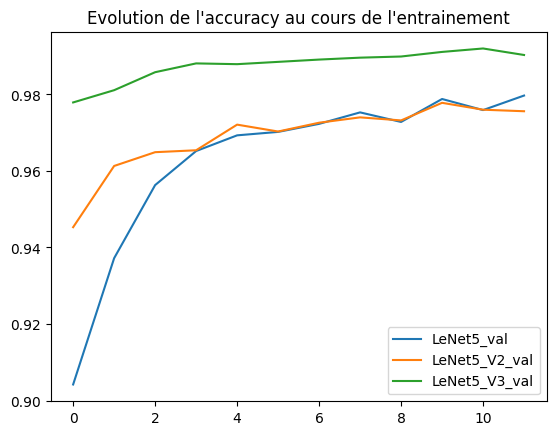

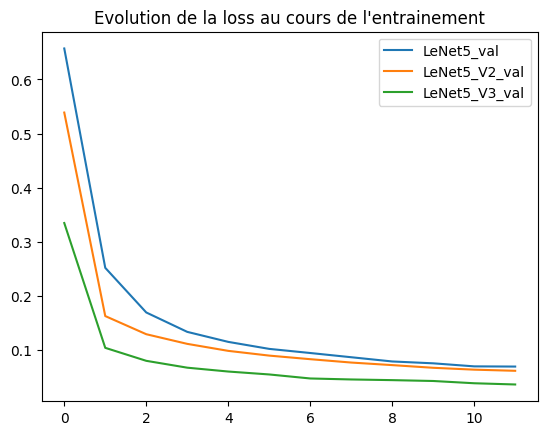

In [ ]:
pd.DataFrame(acc, columns= [x for x in acc if "val" in x]).plot(title="Evolution de l'accuracy au cours de l'entrainement") 
pd.DataFrame(loss, columns= [x for x in acc if "val" in x]).plot(title="Evolution de la loss au cours de l'entrainement")

In [ ]:
model.save(MODEL_FOLDER+"/"+nom+".keras")


b) Créer un autre modèle reproduisant LeNet-5 mais avec les modifications suivantes : 
- utiliser des activations *ReLU* au lieu de *Tanh*
- Utilisation *Softmax* en sortie
- utiliser des *pooling*s appliquant le maximum au lieu de la moyenne

Le modèle, une fois entraîné, sera stocké dans un fichier afin de pouvoir être utilisée ultérieurement. 
Comparer les résultats obtenus avec les résultats précédents en utilisant le même paramétrage.

c) Créer un 3ème modèle dont la structure sera la suivante : 
- 32 convolutions 3×3, avec zero-padding, suivie de ReLU
- Max-pooling 2×2
- 64 convolutions 3×3, suivie de ReLU
- Max-pooling 2×2
- Applatissement des données, suivi d'un Dropout de probabilité 0.5
- Couche dense de 10 neurones suivie de softmax

Le modèle, une fois entraîné, sera stocké dans un fichier afin de pouvoir être utilisée ultérieurement. 
Comparer les résultats obtenus avec les résultats précédents en utilisant le même paramétrage.

#### Conseils : 
- Les différents modèles peuvent être stockées dans un dictionnaire. Une boucle peut appliquer l'apprentissage sur chaque modèle. Durant cette boucle les résultats pourront être stcokées dans un dictionnaire de résultats et la structure du réseau stockées dans un fichier.
- Quelques méthodes avancées à explorer : 
    - Utiliser des méthodes de gradients améliorées telle que ***Adam***
    - Mettre en place la méthode de "Early Stopping" pour faciliter le paramétrage du nombre d'itérations
    - Ajouter des couches de "Data Augmentation"


## Exercice 2
Reproduire l'exercice 1 en utilisant les données *Fashion MNIST* (datasets "fashion_mnist" dans Keras). Vous pourrez observer les données d'entrées en utilisant les mêmes fonctions d'affichage que pour MNIST.

Description des sorties *Fashion MNIST* : 

| Label |	Description |
| --- | --- |
| 0 	| T-shirt/top
| 1 	| Trouser
| 2 	| Pullover
| 3 	| Dress
| 4 	| Coat
| 5 	| Sandal
| 6 	| Shirt
| 7 	| Sneaker
| 8 	| Bag
| 9 	| Ankle boot


In [3]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_val, y_val) = fashion_mnist.load_data()
# - On normalise en divisant par 255 (valeur maximale d'un pixel)
X_train = X_train / 255
X_val = X_val / 255

acc = {}
loss = {}

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4]


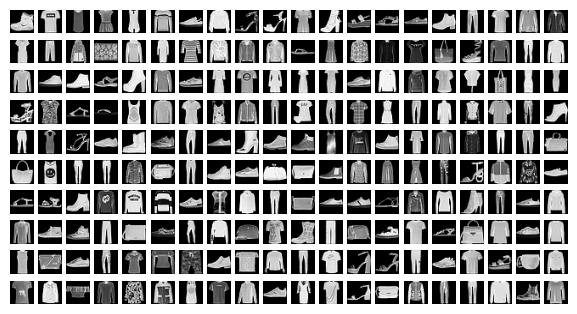

In [6]:
show_data_img(X_train)
print(y_train[:20])

In [9]:
# - Quelles sont les dimensions des différents ensembles (forme, taille) ?
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (60000, 28, 28)
X_val shape: (10000, 28, 28)
y_train shape: (60000,)
y_val shape: (10000,)


In [10]:
# - On normalise en divisant par 255 (valeur maximale d'un pixel)
X_train = X_train / 255
X_val = X_val / 255

In [11]:
def LeNet5():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(28,28,1)))

    m.add(layers.Conv2D(6, kernel_size=(5,5), strides=2, activation='tanh'))
    m.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))
    m.add(layers.Conv2D(16, kernel_size=(5,5), activation='tanh'))
    m.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(120, activation='tanh'))
    m.add(keras.layers.Dense(84, activation='tanh'))
    m.add(keras.layers.Dense(10, activation='sigmoid'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5"


def LeNet5_V2():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(28,28,1)))

    m.add(layers.Conv2D(6, kernel_size=(5,5), strides=2, activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
    m.add(layers.Conv2D(16, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(120, activation='relu'))
    m.add(keras.layers.Dense(84, activation='relu'))
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5_V2"


# c) Créer un 3ème modèle dont la structure sera la suivante : 
# - 32 convolutions 3×3, avec zero-padding, suivie de ReLU
# - Max-pooling 2×2
# - 64 convolutions 3×3, suivie de ReLU
# - Max-pooling 2×2
# - Applatissement des données, suivi d'un Dropout de probabilité 0.5
# - Couche dense de 10 neurones suivie de softmax

# Le modèle, une fois entraîné, sera stocké dans un fichier afin de pouvoir être utilisée ultérieurement. 
# Comparer les résultats obtenus avec les résultats précédents en utilisant le même paramétrage.

def LeNet5_V3():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(28,28,1)))

    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dropout(0.5))
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5_V3"

In [14]:
model, nom = LeNet5_V2()
model.summary()

taille_batch = 128
nb_iterations = 12

s = model.fit(X_train, y_train, batch_size = taille_batch, epochs = nb_iterations, verbose = 1, validation_data= (X_val, y_val))

acc[nom+"_train"] = s.history['accuracy']
acc[nom+"_val"] = s.history['val_accuracy']

loss[nom+"_train"] = s.history['val_loss']
loss[nom+"_val"] = s.history['loss']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,626 (61.04 KB)

 Trainable params: 15,626 (61.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
457/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2726 - loss: 1.9001

KeyboardInterrupt: 

<Axes: title={'center': "Evolution de la loss au cours de l'entrainement"}>

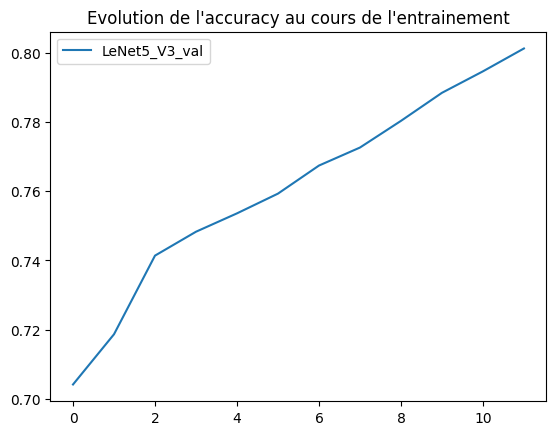

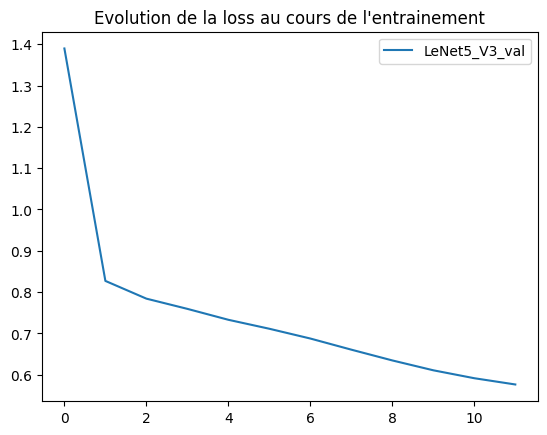

In [13]:
pd.DataFrame(acc, columns= [x for x in acc if "val" in x]).plot(title="Evolution de l'accuracy au cours de l'entrainement") 
pd.DataFrame(loss, columns= [x for x in acc if "val" in x]).plot(title="Evolution de la loss au cours de l'entrainement")